In [ ]:
"""
Lab 2 - Activity 3 & 4: Movement Classification
-------------------------------------------------
"""

from pandas import read_csv
from matplotlib import pyplot
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

(60, 8)
    mean_dist  std_dist  min_dist  max_dist  range_dist  slope  delta  \
0        4.56      0.04      4.51      4.62        0.11 -0.006  -0.03   
1        4.61      0.10      4.35      4.73        0.38  0.008   0.01   
2        4.53      0.17      4.32      4.88        0.56 -0.007   0.00   
3        4.54      0.16      4.34      4.75        0.41  0.002  -0.02   
4        4.58      0.10      4.40      4.79        0.39 -0.022  -0.22   
5        4.52      0.14      4.31      4.74        0.43 -0.022  -0.43   
6        4.58      0.14      4.34      4.83        0.49 -0.021  -0.25   
7        4.52      0.22      3.95      4.71        0.76 -0.048  -0.73   
8        4.56      0.07      4.49      4.70        0.21 -0.008  -0.05   
9        4.56      0.05      4.49      4.67        0.18  0.002   0.08   
10       4.57      0.06      4.45      4.65        0.20 -0.001  -0.09   
11       4.51      0.15      4.24      4.68        0.44 -0.015  -0.30   
12       4.51      0.18      4.29      4.73

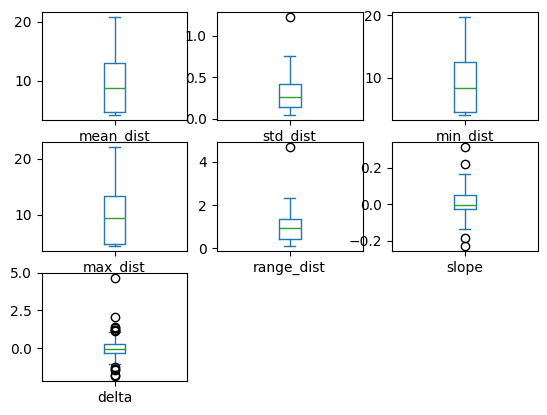

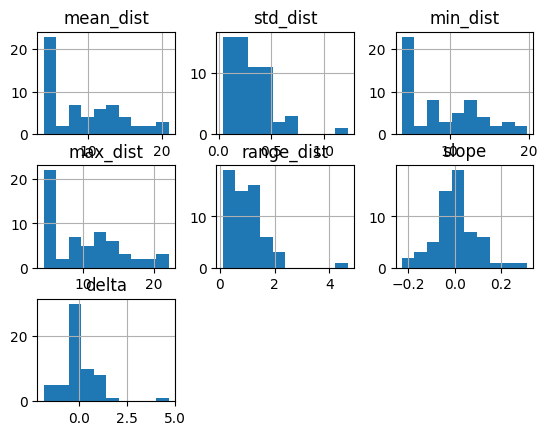

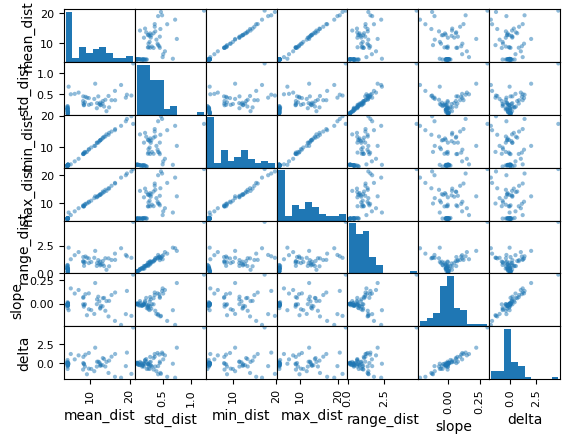

In [ ]:
# ---------------------------------------------------------------------------
# Load dataset
# ---------------------------------------------------------------------------
# One row per ~1.5s window of sensor readings, reduced to 7 engineered
# features. mean/std/min/max/range describe the distance distribution
# within the window; slope and delta capture DIRECTION and SPEED of
# movement, which a single instantaneous reading can't -- that's the key
# difference from the flat iris columns.
dataset = read_csv("movement_data.csv")

print(dataset.shape)
print(dataset.head(20))
print(dataset.describe())
print(dataset.groupby("label").size())  # check class balance across movement types -- uneven
                                          # counts here will skew the accuracy scores below

dataset.plot(kind="box", subplots=True, layout=(3, 3), sharex=False, sharey=False)
pyplot.show()

dataset.hist()
pyplot.show()

scatter_matrix(dataset)
pyplot.show()


In [ ]:
# ---------------------------------------------------------------------------
# Split-out validation dataset
# ---------------------------------------------------------------------------
FEATURE_COLS = ["mean_dist", "std_dist", "min_dist", "max_dist", "range_dist", "slope", "delta"]
X = dataset[FEATURE_COLS].values
y = dataset["label"].values

X_train, X_validation, Y_train, Y_validation = train_test_split(
    X, y, test_size=0.20, random_state=1, shuffle=True, stratify=y
)
# stratify=y keeps label proportions consistent between train/validation --
# worth having given this dataset is likely much smaller than iris's 150 rows.



In [ ]:
# ---------------------------------------------------------------------------
# Activity 3: same three algorithms as the walkthrough, applied to our data
# ---------------------------------------------------------------------------
models = [
    ("KNN", KNeighborsClassifier()),
    ("CART", DecisionTreeClassifier()),
    ("SVM", SVC(gamma="auto")),
]

results, names = [], []
kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
for name, model in models:
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring="accuracy")
    results.append(cv_results)
    names.append(name)
    print("%s: %f (%f)" % (name, cv_results.mean(), cv_results.std()))

KNN: 0.705000 (0.210297)
CART: 0.840000 (0.149666)
SVM: 0.790000 (0.170000)


In [ ]:

# Make predictions on the validation dataset
model = SVC(gamma="auto")
model.fit(X_train, Y_train)
predictions = model.predict(X_validation)

print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))
# away, towards, not moving

0.6666666666666666
[[3 1 0]
 [2 2 0]
 [1 0 3]]
                precision    recall  f1-score   support

   moving_away       0.50      0.75      0.60         4
moving_towards       0.67      0.50      0.57         4
    not_moving       1.00      0.75      0.86         4

      accuracy                           0.67        12
     macro avg       0.72      0.67      0.68        12
  weighted avg       0.72      0.67      0.68        12



In [ ]:
# mean_dist is ~0-400cm, std_dist is usually single
# digits, slope is often < 1. KNN and SVM are distance-based, so a
# large-range feature can dominate the distance calculation even if it's not
# actually more informative. Standardizing (mean 0, std 1) fixes that.
scaled_svm = make_pipeline(StandardScaler(), SVC(gamma="auto"))
scaled_scores = cross_val_score(scaled_svm, X_train, Y_train, cv=kfold, scoring="accuracy")
print("SVM with scaling: %f (%f)" % (scaled_scores.mean(), scaled_scores.std()))
# Compare directly against the un-scaled SVM result printed above.

SVM with scaling: 0.900000 (0.134164)
